In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('/content/heart_disease_uci (1).csv')
df = data.copy()
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(920, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


**Missing values in resting blood pressure were imputed using the median value within age and sex groups to preserve physiological relationships and reduce the impact of outliers**

In [ ]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)

In [ ]:
df['age_bin'] = pd.cut(
    df['age'],
    bins=[20, 30, 40, 50, 60, 70, 80, 100]
)

*Imputing Missing Resting Blood Pressure Using Age and Sex Group Median*

In [ ]:
df['trestbps'] = (
    df.groupby(['age_bin', 'sex'])['trestbps']
      .transform(lambda x: x.fillna(x.median()))
)


/tmp/ipython-input-1687974850.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_bin', 'sex'])['trestbps']


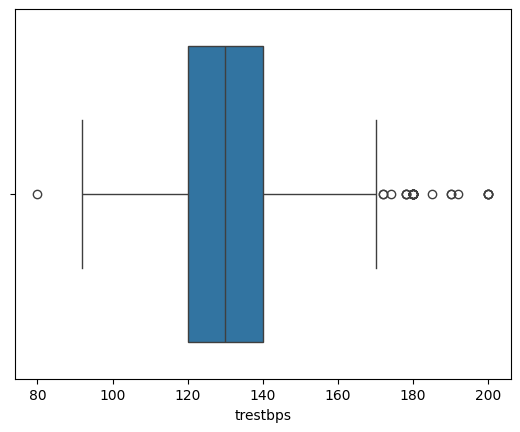

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['trestbps'])
plt.show()


In [ ]:
df['trestbps'].isna().sum()

np.int64(0)

In [ ]:
zeros_tres = (df['trestbps'] == 0).sum()
zeros_tres

np.int64(0)

* Detecting Outliers in Resting Blood Pressure Using IQR Method*

In [ ]:
Q1 = df['trestbps'].quantile(0.25)
Q3 = df['trestbps'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


(np.float64(90.0), np.float64(170.0))

In [ ]:
outliers = df[
    (df['trestbps'] < lower_bound) |
    (df['trestbps'] > upper_bound)
]

len(outliers), len(outliers) / len(df)


(27, 0.029347826086956522)

**Missing values were imputed using age- and sex-based median values, and clinically valid outliers were retained to preserve real pathological cases.**

In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,30
fbs,90
restecg,2
thalch,55


**Analyzing and Imputing Missing Values in Serum Cholesterol (chol)
**

In [ ]:
df['chol'].isna().sum()

np.int64(30)

In [ ]:
correlations = df.select_dtypes(include=[np.number]).corr()['chol'].sort_values(ascending=False)
print("Correlation of Cholesterol with other features:\n", correlations)

Correlation of Cholesterol with other features:
 chol        1.000000
thalch      0.236121
trestbps    0.075702
ca          0.051606
oldpeak     0.047734
age        -0.086234
num        -0.231547
id         -0.376936
Name: chol, dtype: float64


*# A graph showing the distribution of cholesterol by sex and age*

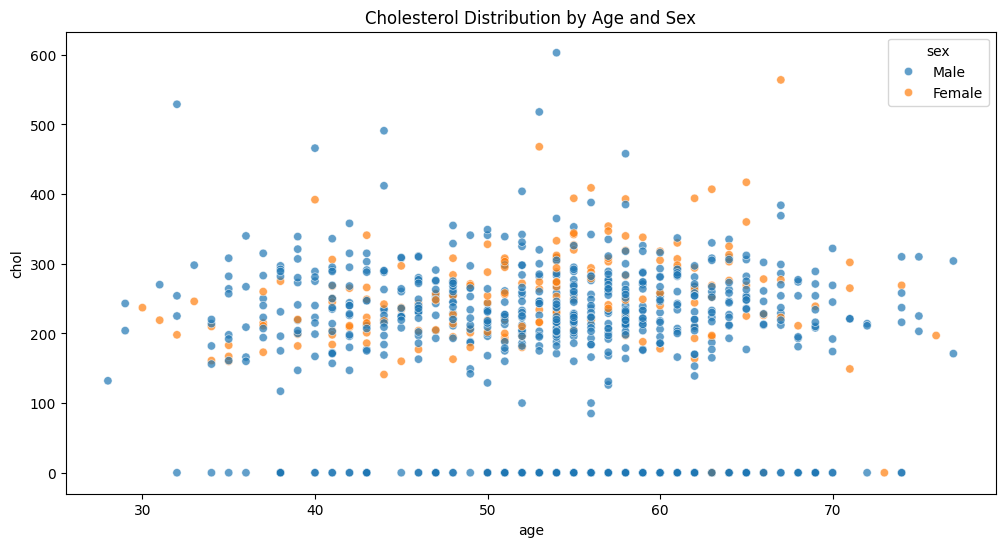

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='age', y='chol', hue='sex', alpha=0.7)
plt.title('Cholesterol Distribution by Age and Sex')
plt.show()

*Detecting Zero values in Cholesterol and their distribution*

In [ ]:
zero_chol = (df['chol'] == 0).sum()
zero_chol

np.int64(172)

In [ ]:
zero_dist = df[df['chol'] == 0]['dataset'].value_counts()
print("\nDistribution of zeros across datasets:\n", zero_dist)


Distribution of zeros across datasets:
 dataset
Switzerland      123
VA Long Beach     49
Name: count, dtype: int64


*Calculating the total number of patients in the Switzerland dataset*

In [ ]:
# Calculating the total number of patients in Switzerland
total_switzerland = df[df['dataset'] == 'Switzerland'].shape[0]

# Calculating the number of people with 0 cholesterol in Switzerland
zeros_switzerland = df[(df['dataset'] == 'Switzerland') & (df['chol'] == 0)].shape[0]

# Calculation in percentage
percent_missing = (zeros_switzerland / total_switzerland) * 100

print(f"Total patients in Switzerland: {total_switzerland}")
print(f"Patients with 0 cholesterol in Switzerland: {zeros_switzerland}")
print(f"Percentage of missing cholesterol in Switzerland: {percent_missing:.2f}%")

Total patients in Switzerland: 123
Patients with 0 cholesterol in Switzerland: 123
Percentage of missing cholesterol in Switzerland: 100.00%


*Visualizing Cholesterol levels across different Datasets*

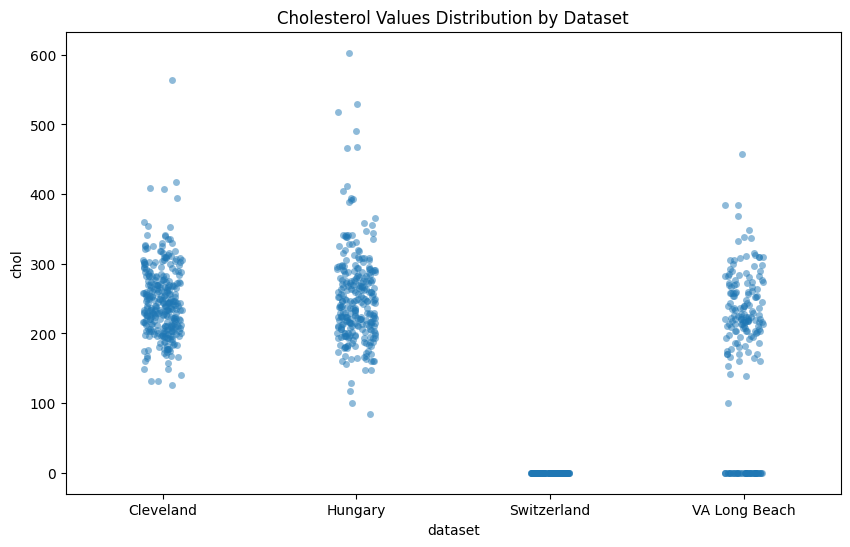

In [ ]:
plt.figure(figsize=(10, 6))
sns.stripplot(x='dataset', y='chol', data=df, jitter=True, alpha=0.5)
plt.title('Cholesterol Values Distribution by Dataset')
plt.show()

*Converting Zero values to NaN *

In [ ]:
df['chol'] = df['chol'].replace(0, np.nan)

print(f"Total missing values: {df['chol'].isnull().sum()}")

Total missing values: 202


**Imputing Cholesterol using Sex and age_bin**

In [ ]:
df['chol'] = df.groupby(['sex', 'age_bin'])['chol'].transform(
    lambda x: x.fillna(x.median()))

/tmp/ipython-input-4175491861.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['chol'] = df.groupby(['sex', 'age_bin'])['chol'].transform(


In [ ]:
df['chol'].isnull().sum()

np.int64(0)

In [ ]:
# The new average size offer in Switzerland compared to other places
print("Mean Cholesterol after cleaning:")
print(df.groupby('dataset')['chol'].mean())

# Delete the age group column
df.drop('age_bin', axis=1, inplace=True)

Mean Cholesterol after cleaning:
dataset
Cleveland        246.315789
Hungary          250.075085
Switzerland      238.666667
VA Long Beach    239.117500
Name: chol, dtype: float64


In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Analyzing and Imputing Missing Values in thalch

Two ways :
* 1)Use the "statistical median" for each age group*
* 2)Using the "Medical Equation" (220 - Age)*

**Visualizing Age-based Median Imputation for thalch**



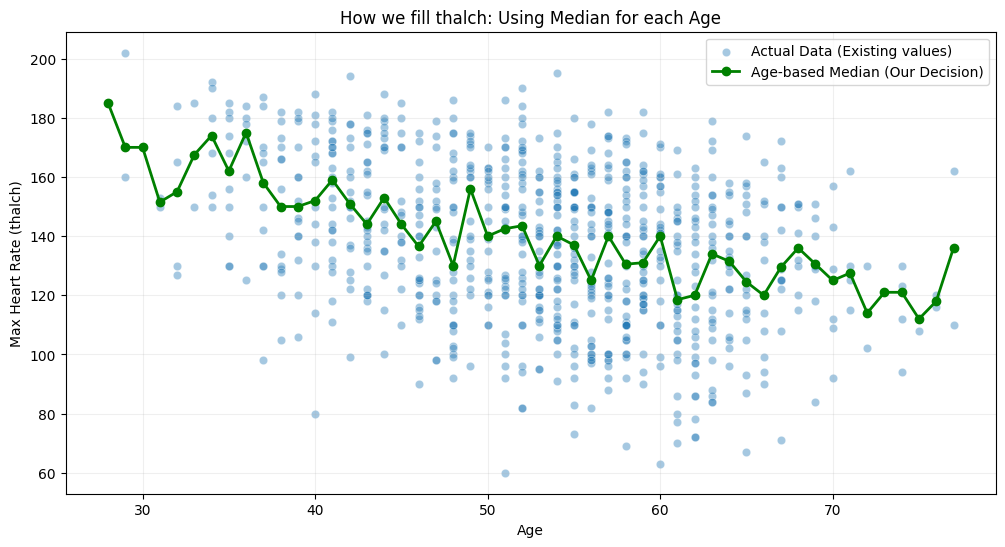

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the median for each age (draw it as a reference line)
age_medians = df.groupby('age')['thalch'].median()

# Draw the original data and draw the "medial line"
plt.figure(figsize=(12, 6))

#Drawing the actual points for patients
sns.scatterplot(data=df, x='age', y='thalch', alpha=0.4, label='Actual Data (Existing values)')

# Draw the median line (which represents our decision in filling in the gaps)
plt.plot(age_medians.index, age_medians.values, color='green', linewidth=2, marker='o', label='Age-based Median (Our Decision)')

plt.title('How we fill thalch: Using Median for each Age')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalch)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

**Comparing Actual Data vs. Medical Formula (220-Age)**

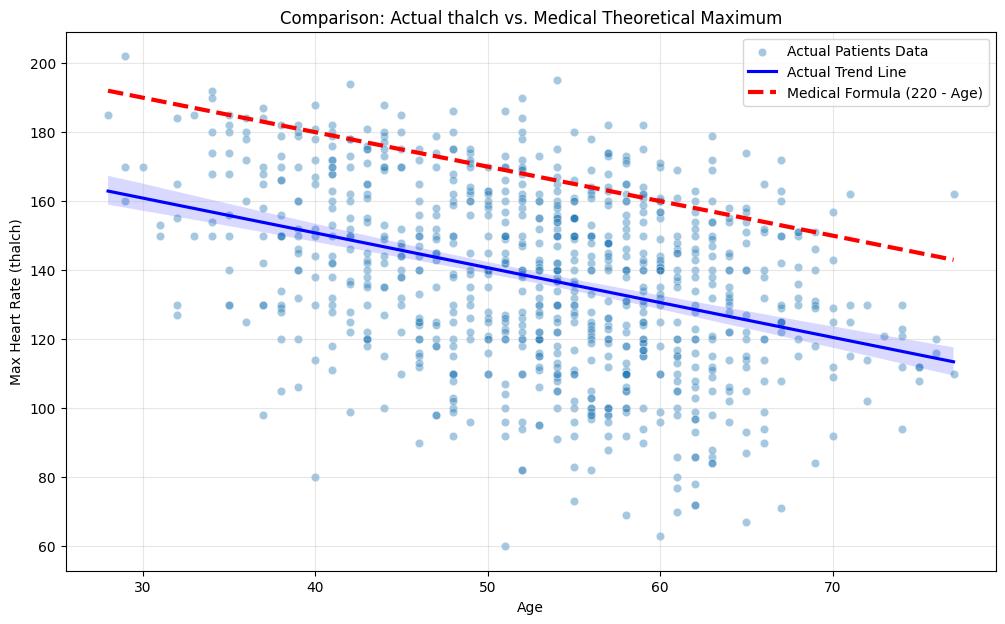

In [ ]:
ages_range = np.linspace(df['age'].min(), df['age'].max(), 100)
medical_formula = 220 - ages_range

plt.figure(figsize=(12, 7))

sns.scatterplot(data=df, x='age', y='thalch', alpha=0.4, label='Actual Patients Data')
sns.regplot(data=df, x='age', y='thalch', scatter=False, color='blue', label='Actual Trend Line')

plt.plot(ages_range, medical_formula, color='red', linewidth=3, linestyle='--', label='Medical Formula (220 - Age)')

plt.title('Comparison: Actual thalch vs. Medical Theoretical Maximum')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalch)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

***Based on the graph, the first option, "Statistical Median per Age," is the most appropriate because it reflects the actual condition of patients under the test conditions and does not assume perfect health like the theoretical equation.***

**mputing thalch based on Empirical Data (Age Median)**

In [ ]:
# Impute using median for each specific age
df['thalch'] = df.groupby('age')['thalch'].transform(lambda x: x.fillna(x.median()))

# Handle rare cases using age bins (decades)
if df['thalch'].isnull().sum() > 0:

    df['age_group_tmp'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 70, 80, 100])

    # Fill in the missing information based on the median age group
    df['thalch'] = df.groupby('age_group_tmp', observed=False)['thalch'].transform(lambda x: x.fillna(x.median()))

    df.drop('age_group_tmp', axis=1, inplace=True)
# Final validation
print(f"Missing values in 'thalch' after process: {df['thalch'].isnull().sum()}")

Missing values in 'thalch' after process: 0


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,90
restecg,2
thalch,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


**Analyzing and Imputing Missing Values in FBS**

*Distribution of Fasting Blood Sugar (fbs) across different Datasets*

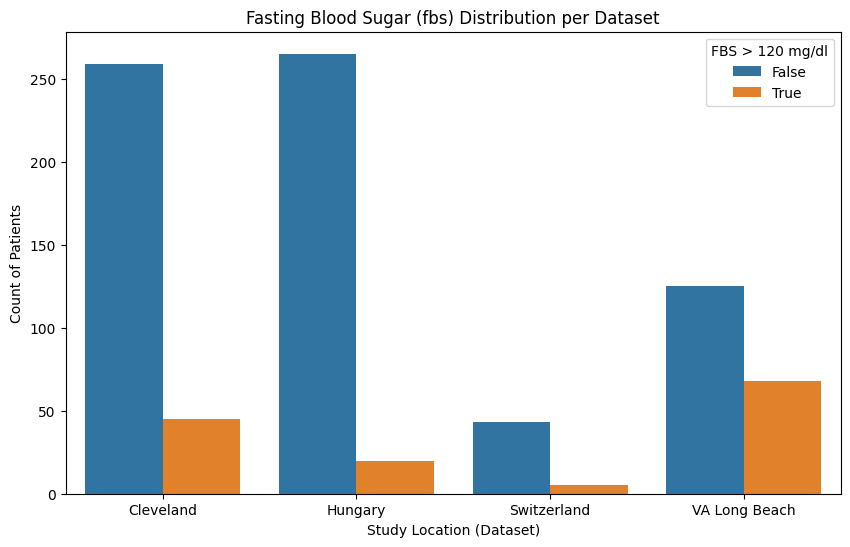

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='dataset', hue='fbs', data=df)
plt.title('Fasting Blood Sugar (fbs) Distribution per Dataset')
plt.xlabel('Study Location (Dataset)')
plt.ylabel('Count of Patients')
plt.legend(title='FBS > 120 mg/dl', labels=['False', 'True'])
plt.show()

*FBS distribution by Sex and Age Groups*

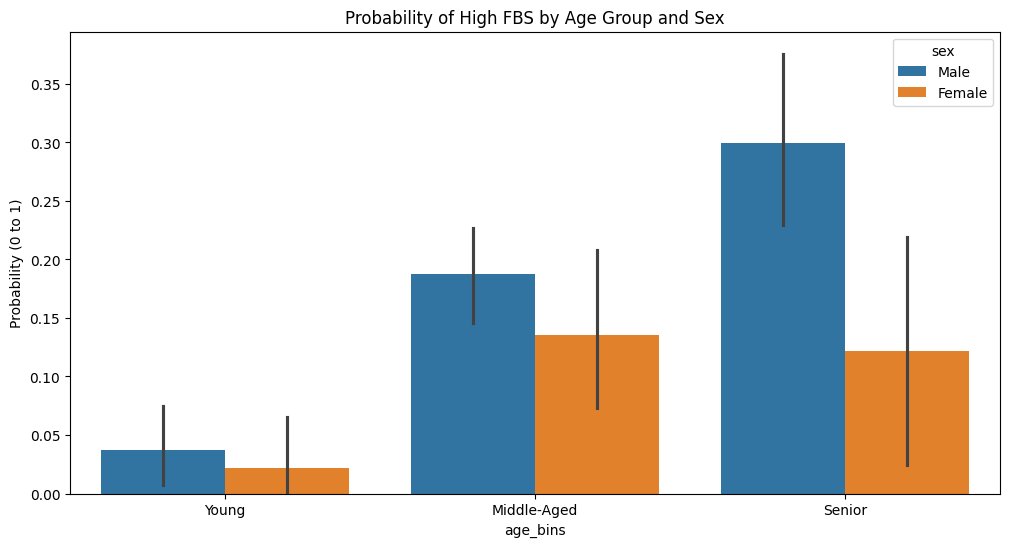

In [ ]:
df['age_bins'] = pd.cut(df['age'], bins=[0, 45, 60, 100], labels=['Young', 'Middle-Aged', 'Senior'])

plt.figure(figsize=(12, 6))
sns.barplot(x='age_bins', y=df['fbs'].map({True: 1, False: 0}), hue='sex', data=df)
plt.title('Probability of High FBS by Age Group and Sex')
plt.ylabel('Probability (0 to 1)')
plt.show()

*Imputing FBS using Mode within Dataset and Sex groups*

In [ ]:
def get_mode(x):
    m = x.mode()
    return m[0] if not m.empty else False

df['fbs'] = df.groupby(['dataset', 'sex'])['fbs'].transform(lambda x: x.fillna(get_mode(x)))

print(f"Missing values in 'fbs' after imputation: {df['fbs'].isnull().sum()}")

df.drop('age_bins', axis=1, inplace=True, errors='ignore')

Missing values in 'fbs' after imputation: 0


/tmp/ipython-input-2514951540.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df.groupby(['dataset', 'sex'])['fbs'].transform(lambda x: x.fillna(get_mode(x)))


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,2
thalch,0


**Analyzing and Imputing Missing Values in exang**

*Missing Data Pattern for Exercise Angina (exang) per Dataset*

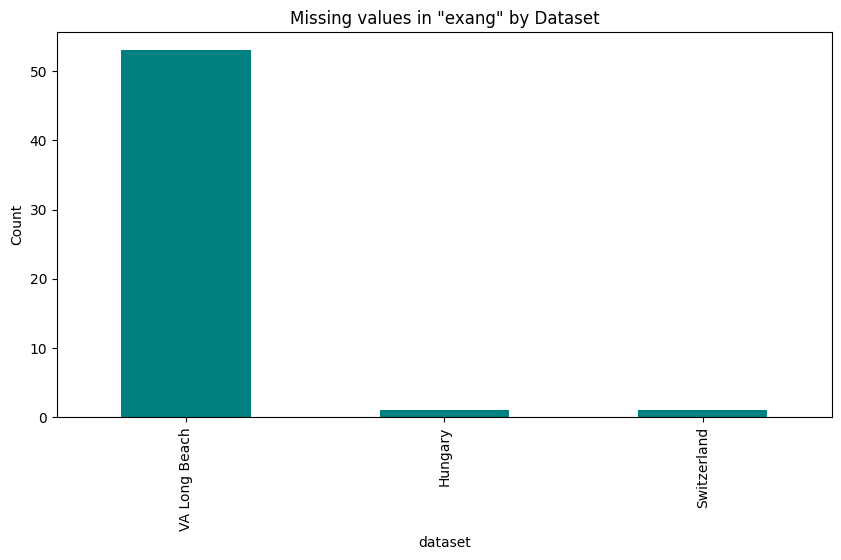

Total missing in exang: 55


In [ ]:
exang_missing = df[df['exang'].isnull()]['dataset'].value_counts()

plt.figure(figsize=(10, 5))
exang_missing.plot(kind='bar', color='teal')
plt.title('Missing values in "exang" by Dataset')
plt.ylabel('Count')
plt.show()

print(f"Total missing in exang: {df['exang'].isnull().sum()}")

*Correlation between Exercise Angina and Chest Pain Type (cp)*

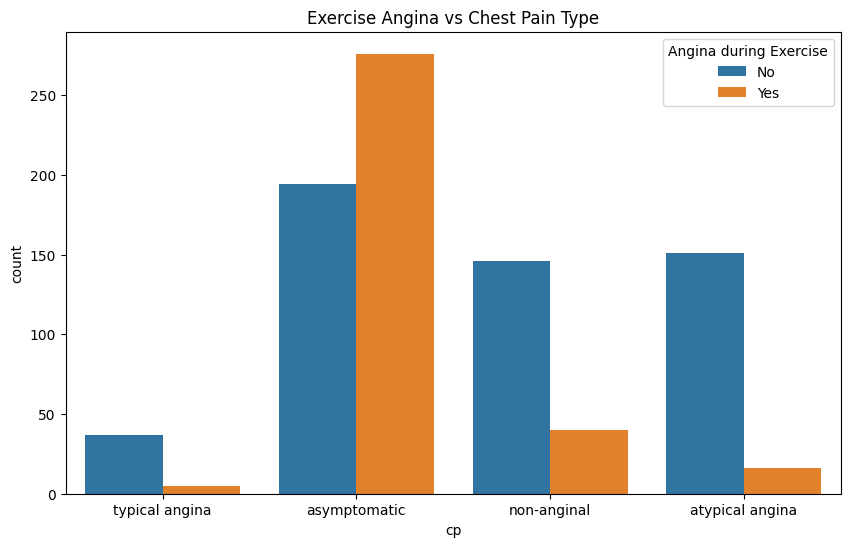

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='cp', hue='exang', data=df.dropna(subset=['exang']))
plt.title('Exercise Angina vs Chest Pain Type')
plt.legend(title='Angina during Exercise', labels=['No', 'Yes'])
plt.show()

*Prevalence of Exercise Angina (exang) by Sex*

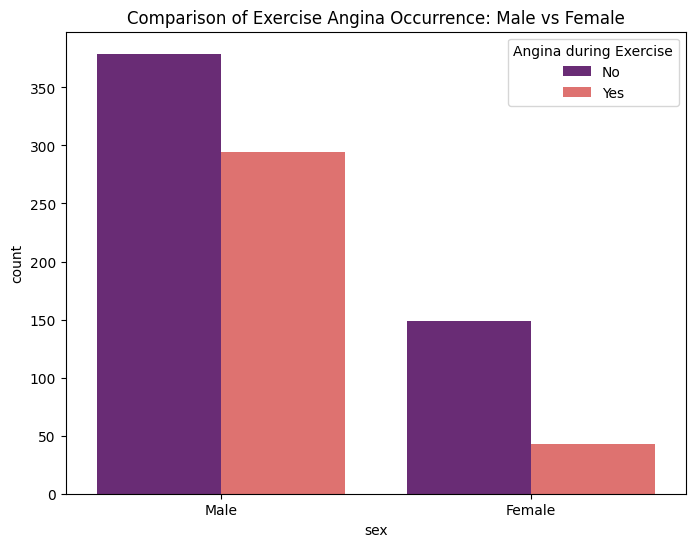

Exang Distribution by Sex (Percentage):
exang       False      True 
sex                         
Female  77.604167  22.395833
Male    56.315007  43.684993


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='exang', data=df.dropna(subset=['exang']), palette='magma')
plt.title('Comparison of Exercise Angina Occurrence: Male vs Female')
plt.legend(title='Angina during Exercise', labels=['No', 'Yes'])
plt.show()

print("Exang Distribution by Sex (Percentage):")
print(pd.crosstab(df['sex'], df['exang'], normalize='index') * 100)

*Imputation of Exercise Angina (exang) based on Clinical Correlations (Sex & CP)*

In [ ]:
def fill_mode(x):
    if x.isnull().all():
        return x
    return x.fillna(x.mode()[0])

df['exang'] = df.groupby(['sex', 'cp'])['exang'].transform(fill_mode)

df['exang'] = df.groupby('sex')['exang'].transform(fill_mode)

print(f"Final Missing values in 'exang': {df['exang'].isnull().sum()}")

Final Missing values in 'exang': 0


/tmp/ipython-input-1008357403.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return x.fillna(x.mode()[0])


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,2
thalch,0
